Classification after Clustering 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay




warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)
# Create Dataframe
df = pd.read_csv(r"./data1/clustered_data.csv")
# Print shape of dataset
print(df.shape)

(2240, 22)


Split X and Y

In [2]:
x = df.drop("cluster", axis = 1)
y = df["cluster"]

Grid Search

Select the best model

In [3]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve,confusion_matrix

from sklearn import metrics 

models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
    
    "AdaBoost Classifier": AdaBoostClassifier()
}

<b>We will create a generic function to check each model's performance so that we can compare those</b>

In [4]:
# Create a function which can evaluate models and return a report 
def evaluate_models(X, y, models):
    '''
    This function takes in X and y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    '''
    # separate dataset into train and test
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    

    models_list = []
    scores = []
    
    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train) # Train model

        # Make predictions
        y_pred = model.predict(X_test)

        score = accuracy_score(y_test,y_pred)
        
        model_name = list(models.keys())[i]
        print(f'---- score for --- {model_name} ----')
        print(f"{score}")
        models_list.append(model_name)
        scores.append(score)
    
    print()
    
    report = pd.DataFrame()
    report['Model_name'] = models_list
    report['Score'] = scores        
    return report

<b>Let's Check the report</b>

In [5]:
report = evaluate_models(x, y, models)

---- score for --- Random Forest ----
0.9709821428571429
---- score for --- Decision Tree ----
0.9464285714285714
---- score for --- Gradient Boosting ----
0.96875
---- score for --- Logistic Regression ----
0.8839285714285714
---- score for --- K-Neighbors Classifier ----
0.8102678571428571
---- score for --- AdaBoost Classifier ----
0.9486607142857143



In [6]:
report.sort_values('Score')

,Model_name,Score
4,K-Neighbors Classifier,0.810268
3,Logistic Regression,0.883929
1,Decision Tree,0.946429
5,AdaBoost Classifier,0.948661
2,Gradient Boosting,0.968750
0,Random Forest,0.970982


<b>From the report above we can see that the logistic regression model performed the best, so we will continue training our model using logistic regression algorithm.</b>

In [7]:
# Split into Train and test data

X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.3)

X_train

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth
994,68,2,0,1,2,64587.0,108.0,4390.0,49,66,0,16,0.0,6,20.0,1,1,4,2,0,3
2162,65,2,1,1,1,47320.0,414.0,4715.0,10,200,19,111,50.0,15,19.0,5,1,8,6,0,6
906,61,2,0,0,0,86429.0,1449.0,4603.0,10,464,28,556,29.0,18,37.0,7,4,7,0,1,2
572,44,1,0,1,1,38593.0,177.0,4672.0,42,51,12,49,17.0,24,24.0,4,1,3,3,0,8
1877,64,2,1,0,0,72905.0,1515.0,4542.0,52,407,81,445,120.5,81,126.5,3,7,9,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,53,2,1,1,2,44078.0,41.0,4393.0,17,24,1,10,2.0,0,4.0,2,0,3,2,0,5
1095,43,2,0,1,1,61825.0,424.0,4709.0,56,162,50,100,55.0,30,27.0,4,2,8,1,0,4
1130,71,3,1,1,1,67381.0,957.0,4913.0,67,815,8,53,11.0,0,70.0,2,2,9,4,1,7
1294,59,4,0,1,2,48918.0,62.0,4461.0,21,52,0,9,0.0,0,1.0,1,0,4,2,0,4


<b>Let's do hyperparameter tuning</b>

In [ ]:
# Grid search cross validation
from sklearn.model_selection import GridSearchCV

parameter = {'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'max_iter': np.random.randint(100,500, 10),
    'multi_class': ['auto', 'ovr', 'multinomial'],
    "C":np.logspace(-3,3,7),
    "penalty":["l1","l2"]}

logreg=LogisticRegression()

logreg_cv=GridSearchCV(logreg,param_grid = parameter,cv=5)
logreg_cv.fit(X_train,y_train)

print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

In [8]:
best_lr_model = LogisticRegression(
     C = 1000, 
    max_iter =  113,
    multi_class =  'auto', 
    penalty =  'l2', 
    solver =  'lbfgs'
    
)

<b>Let's check the report now</b>

In [9]:
best_model = best_lr_model.fit(X_train,y_train)
y_pred = best_model.predict(X_test)
score = accuracy_score(y_test,y_pred)
cr = classification_report(y_test,y_pred)

print("Logistic regression")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

Logistic regression
Accuracy Score value: 0.8899
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       179
           1       0.97      0.95      0.96       259
           2       0.84      0.85      0.85       234

    accuracy                           0.89       672
   macro avg       0.88      0.88      0.88       672
weighted avg       0.89      0.89      0.89       672



<h2><b>Confusion matrix of the model</h2></b>

<b>What is confusion matrix ?</b>

The confusion matrix is a matrix used to determine the performance of the classification models for a given set of test data. It can only be determined if the true values for test data are known. The matrix itself can be easily understood, but the related terminologies may be confusing.

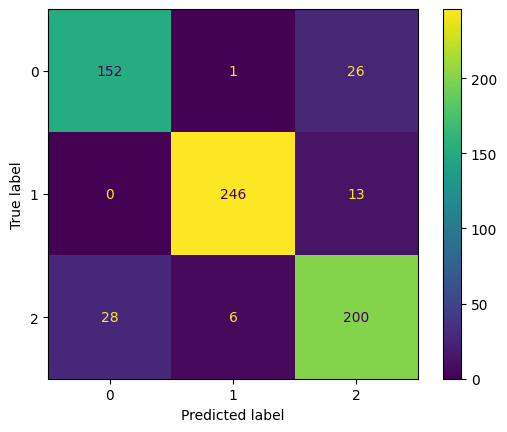

In [10]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)

<b>Reports</b>

We can see, that the modelperformed pretty well.

> we have used logistic regression as it performed well than other models
> 
> We got a good accuracy while predicting the test dataset.

In [11]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Model saved successfully!")

Model saved successfully!


In [19]:
print(x.dtypes)

Age                     int64
Education               int64
Marital Status          int64
Parental Status         int64
Children                int64
Income                float64
Total_Spending        float64
Days_as_Customer      float64
Recency                 int64
Wines                   int64
Fruits                  int64
Meat                    int64
Fish                  float64
Sweets                  int64
Gold                  float64
Web                     int64
Catalog                 int64
Store                   int64
Discount Purchases      int64
Total Promo             int64
NumWebVisitsMonth       int64
dtype: object


In [17]:
print(best_model.classes_)


[0 1 2]


In [16]:
print(x.head())

   Age  Education  Marital Status  Parental Status  Children   Income  \
0   65          2               0                0         0  58138.0   
1   68          2               0                1         2  46344.0   
2   57          2               1                0         0  71613.0   
3   38          2               1                1         1  26646.0   
4   41          4               1                1         1  58293.0   

   Total_Spending  Days_as_Customer  Recency  Wines  Fruits  Meat   Fish  \
0          1617.0            5046.0       58    635      81   546  120.5   
1            27.0            4496.0       38     11       1     6    2.0   
2           776.0            4695.0       26    426      49   127  111.0   
3            53.0            4522.0       26     11       4    20   10.0   
4           422.0            4544.0       94    173      43   118   46.0   

   Sweets  Gold  Web  Catalog  Store  Discount Purchases  Total Promo  \
0      81  88.0    8       10  